 # Squipy Xenium spatial melanoma analysis

## Import packages

In [1]:

import anndata as ad
import os
import numpy as np
import pandas as pd

import spatialdata as sd
from spatialdata_io import xenium

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq

from pathlib import Path
import shutil

import squidpy as sq
from IPython.display import display
import warnings
warnings.filterwarnings("ignore") 

import scipy.sparse as sparse
from scipy.io import mmread
from scipy.stats import pearsonr, pointbiserialr

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib import rc_context

# import scanpy as sc
# sc.logging.print_header()
# sc.set_figure_params(facecolor="white", figsize=(8, 8))
# sc.settings.verbosity = 1 # errors (0), warnings (1), info (2), hints (3)
# plt.rcParams["font.family"] = "Arial"
# sns.set_style("white")

import random
# Note that BANKSY itself is deterministic, here the seeds affect the umap clusters and leiden partition
seed = 1234
np.random.seed(seed)
random.seed(seed)

#import dask
#dask.config.set({"dataframe.query-planning": True})

/home/nnataren/miniforge3/envs/banksy/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


## Set file paths and read in xenium data

In [2]:
## Set the dataset_name and related settings to use during this analysis
dataset_name = "GR_lung_non_res_roi"

pca_label = "35"
pca_dims = int(pca_label)
pca_dims = [pca_dims]

lambda_label = "0.20"
lambda_list = [float(lambda_label)]

res_label = "0.50"
resolutions = [float(res_label)]

nbr_weight_decay = "scaled_gaussian"

# Keys to specify coordinate indexes in the anndata Object
coord_keys = ('x', 'y', 'xy')

In [3]:
## Create a base path
base_dir = "data/xenium"

## Create a path to the raw data
raw_path = os.path.join(base_dir,f"raw_data")

if not os.path.isdir(raw_path):
    os.makedirs(raw_path)
    print(f"Directory '{raw_path} successfully.")
    
else:
    print(f"Directory '{raw_path} exists.")

## Create a path for output data
output_path = os.path.join(base_dir,f"output/{dataset_name}")

if not os.path.isdir(output_path):
    os.makedirs(output_path)
    print(f"Directory '{output_path}' created successfully.")
    
else:
    print(f"Directory '{output_path}' already exists.")

## Create path for processed data
processed_path = os.path.join(base_dir,f"processed/{dataset_name}")

if not os.path.isdir(processed_path):
    os.makedirs(processed_path)
    print(f"Directory '{processed_path}' created successfully.")
    
else:
    print(f"Directory '{processed_path}' already exists.")

Directory 'data/xenium/raw_data exists.
Directory 'data/xenium/output/GR_lung_non_res_roi' already exists.
Directory 'data/xenium/processed/GR_lung_non_res_roi' already exists.


In [4]:
# # read in the xenium data
# xenium_path = "/home/nnataren/Documents/Bioinformatics/Xenium_ICI_melanoma/melanoma_ici_res_spatial/data/raw_data/combined_runs_named/output-XETG00067__0029497__Region_1__20240925__042423__HW_brain_res"

# print("parsing the data... ", end="")
# sdata = xenium(
#     path=xenium_path ,
#     n_jobs=8,
#     transcripts=True,
#     cells_boundaries=True,
#     nucleus_boundaries=True,
#     morphology_focus=True,
#     cells_as_circles=True,
# )
# print("done")

In [5]:
pca_dims

[35]

In [6]:
file_path =f"{output_path}/{dataset_name}_clustered_spatial_pc{pca_label}_nc{lambda_label}_r{res_label}.h5ad"

print("Exists?", os.path.exists(file_path))

Exists? True


In [7]:
## Read in the raw AnnData file
adata = ad.read_h5ad(f"{output_path}/{dataset_name}_clustered_spatial_pc{pca_label}_nc{lambda_label}_r{res_label}.h5ad")
#output_path = f"data/xenium/processed/{dataset_name}_xy.h5ad"
adata.obs_keys()


## Read in the banksy_dict dictionary as a .pkl file
## Use gzip to save it with compression
import gzip
import pickle
with gzip.open(f"{output_path}/{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_banksy_dict.pkl.gz", "rb") as f:
    banksy_dict = pickle.load(f)


## Read in the results_df data frame as a .pkl file
with gzip.open(f"{output_path}/results_df_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.pkl.gz", "rb") as f:
    results_df = pickle.load(f)

## Read in max_num_labels

import gzip
import pickle
with open(f"{processed_path}/max_num_labels_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.pkl.gz", "rb") as f:
   max_num_labels = pickle.load(f)

Saving figure at data/xenium/output/GR_lung_non_res_roi/GR_lung_non_res_roi_nonspatial_pc35_nc0.00_r0.50_spatialmap.png
number of labels: 11
---- Ran plot_2d_embeddings in 0.00 s ----

number of labels: 11
---- Ran plot_2d_embeddings in 0.00 s ----

number of labels: 11
---- Ran plot_2d_embeddings in 0.01 s ----

---- Ran row_normalize in 0.00 s ----


matrix multiplying labels x weights x labels-transpose ((11, 30203) x (30203, 30203) x (30203, 11))

Saving full-figure at data/xenium/output/GR_lung_non_res_roi/GR_lung_non_res_roi_nonspatial_pc35_nc0.00_r0.50_full_figure.png
Saving figure at data/xenium/output/GR_lung_non_res_roi/GR_lung_non_res_roi_scaled_gaussian_pc35_nc0.20_r0.50_spatialmap.png
number of labels: 10
---- Ran plot_2d_embeddings in 0.00 s ----

number of labels: 10
---- Ran plot_2d_embeddings in 0.00 s ----

number of labels: 10
---- Ran plot_2d_embeddings in 0.00 s ----

---- Ran row_normalize in 0.00 s ----


matrix multiplying labels x weights x labels-transpose ((1

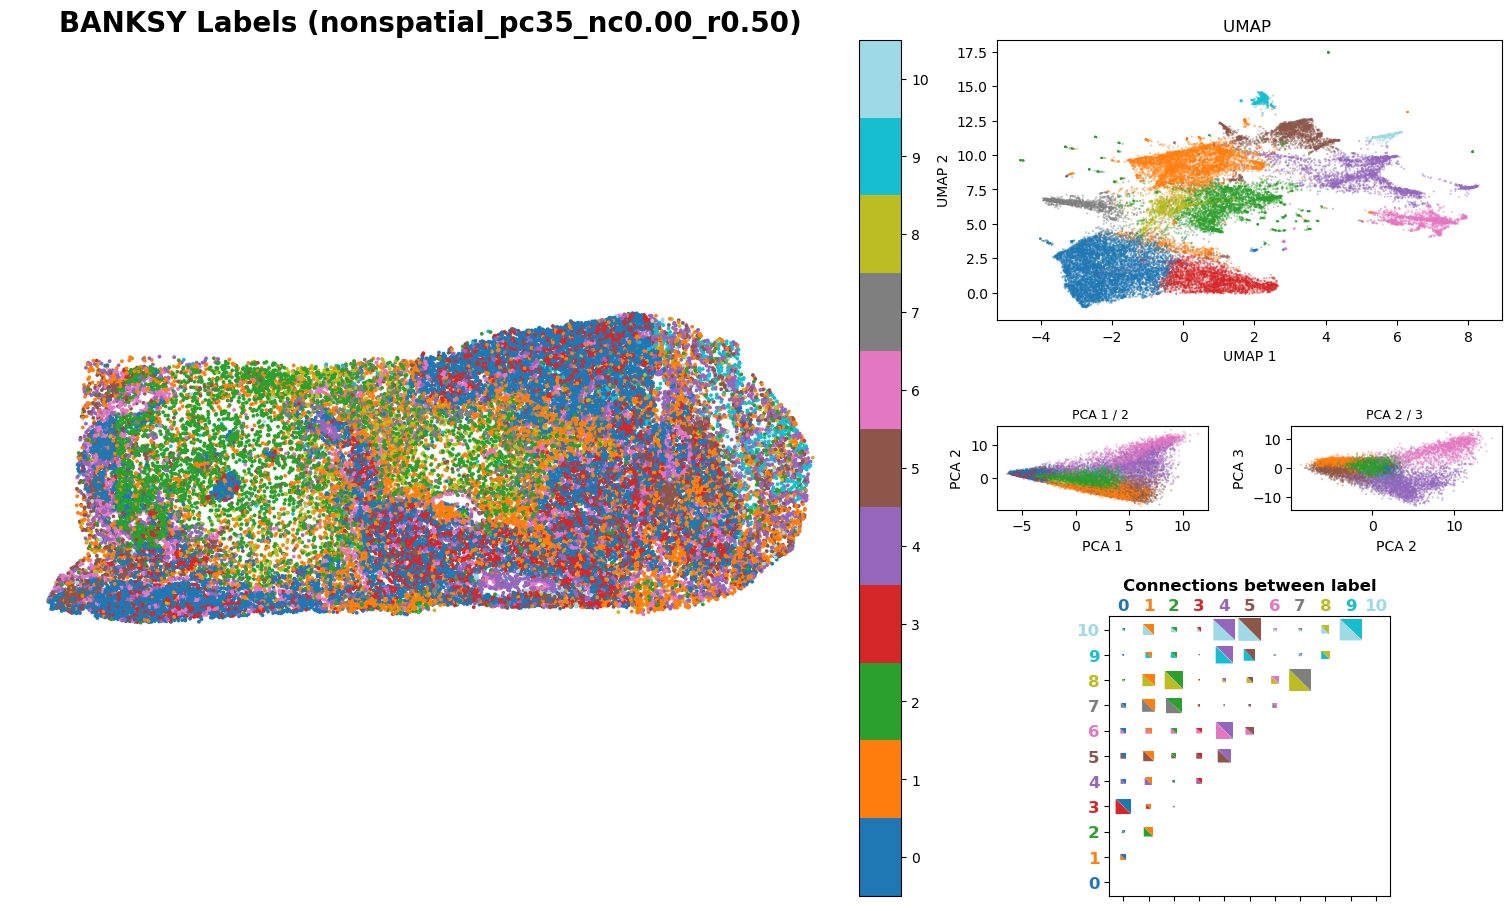

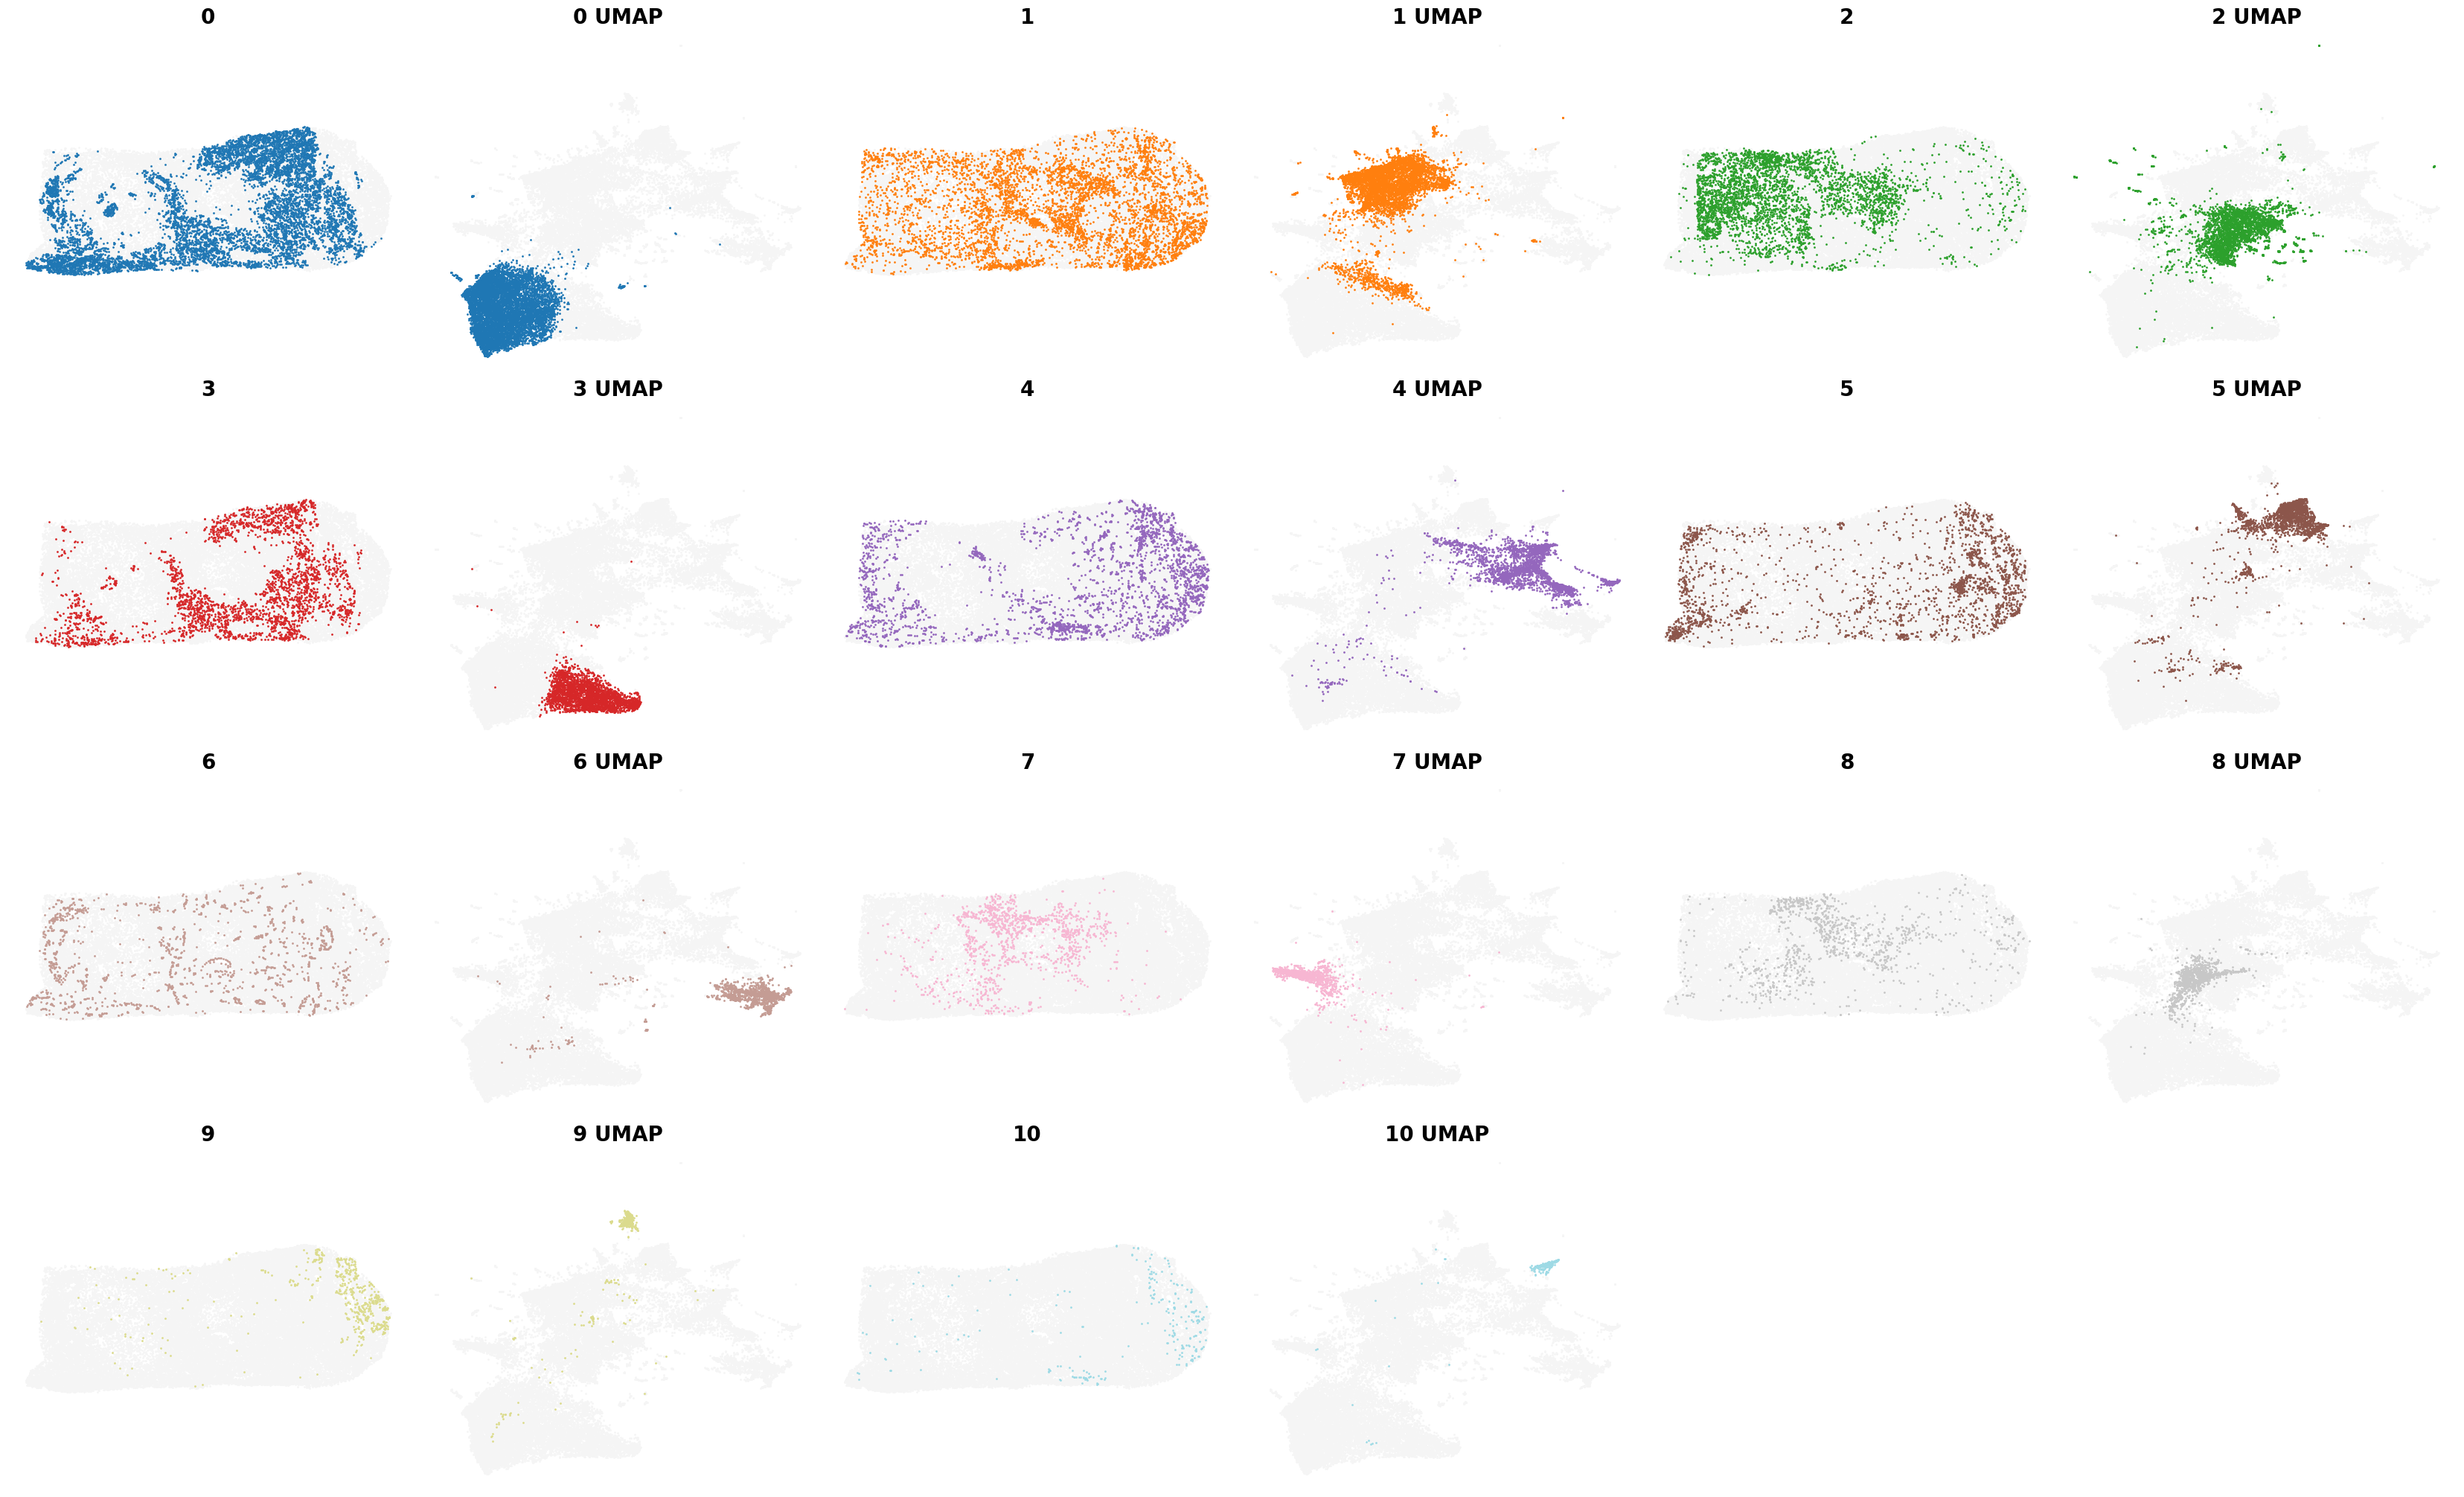

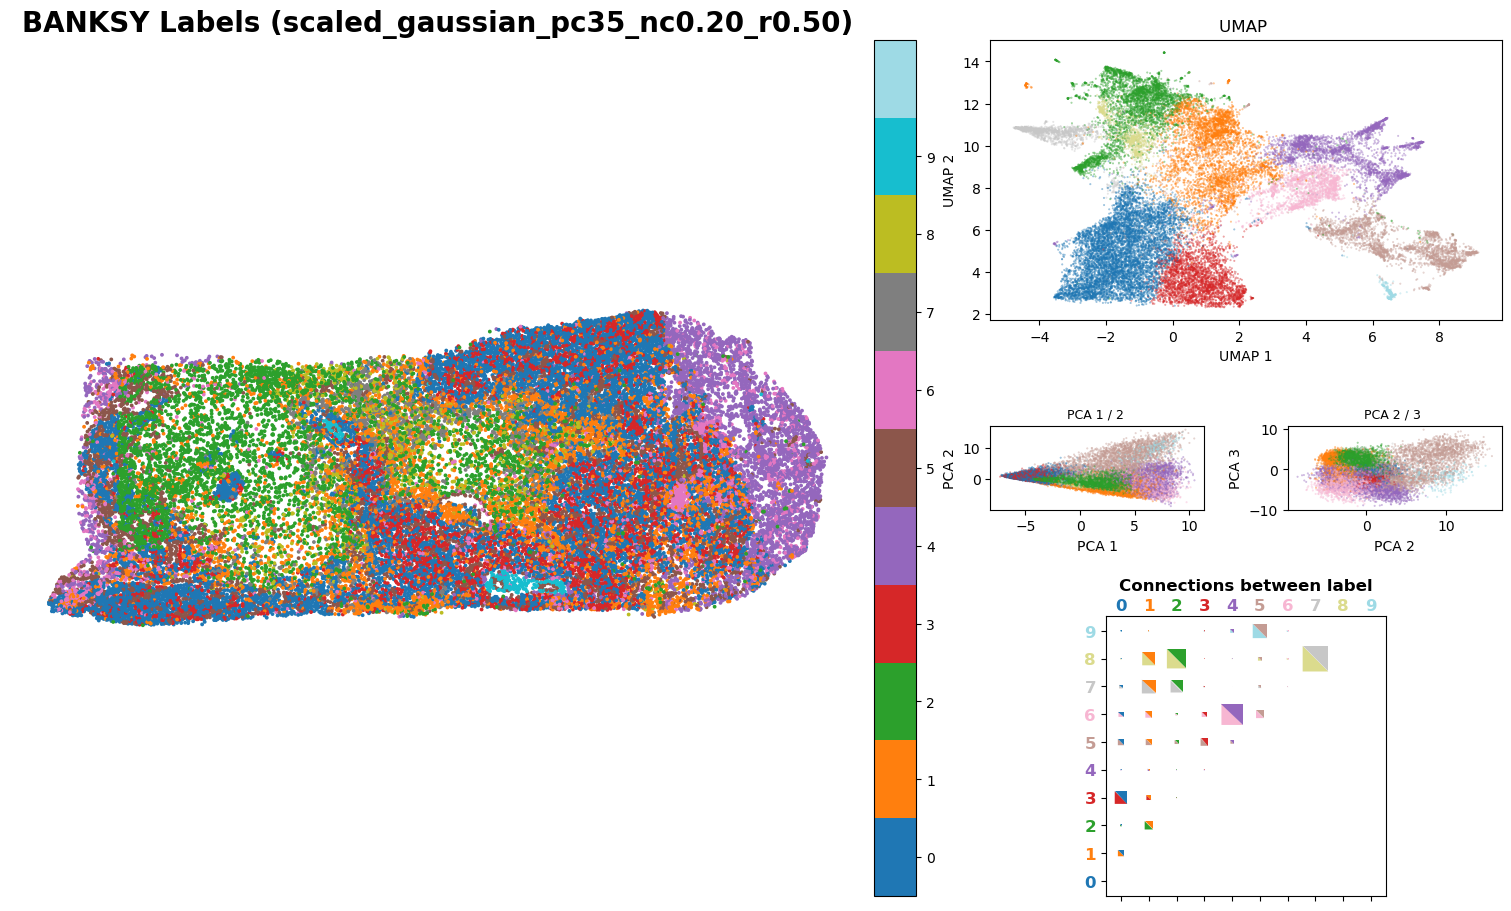

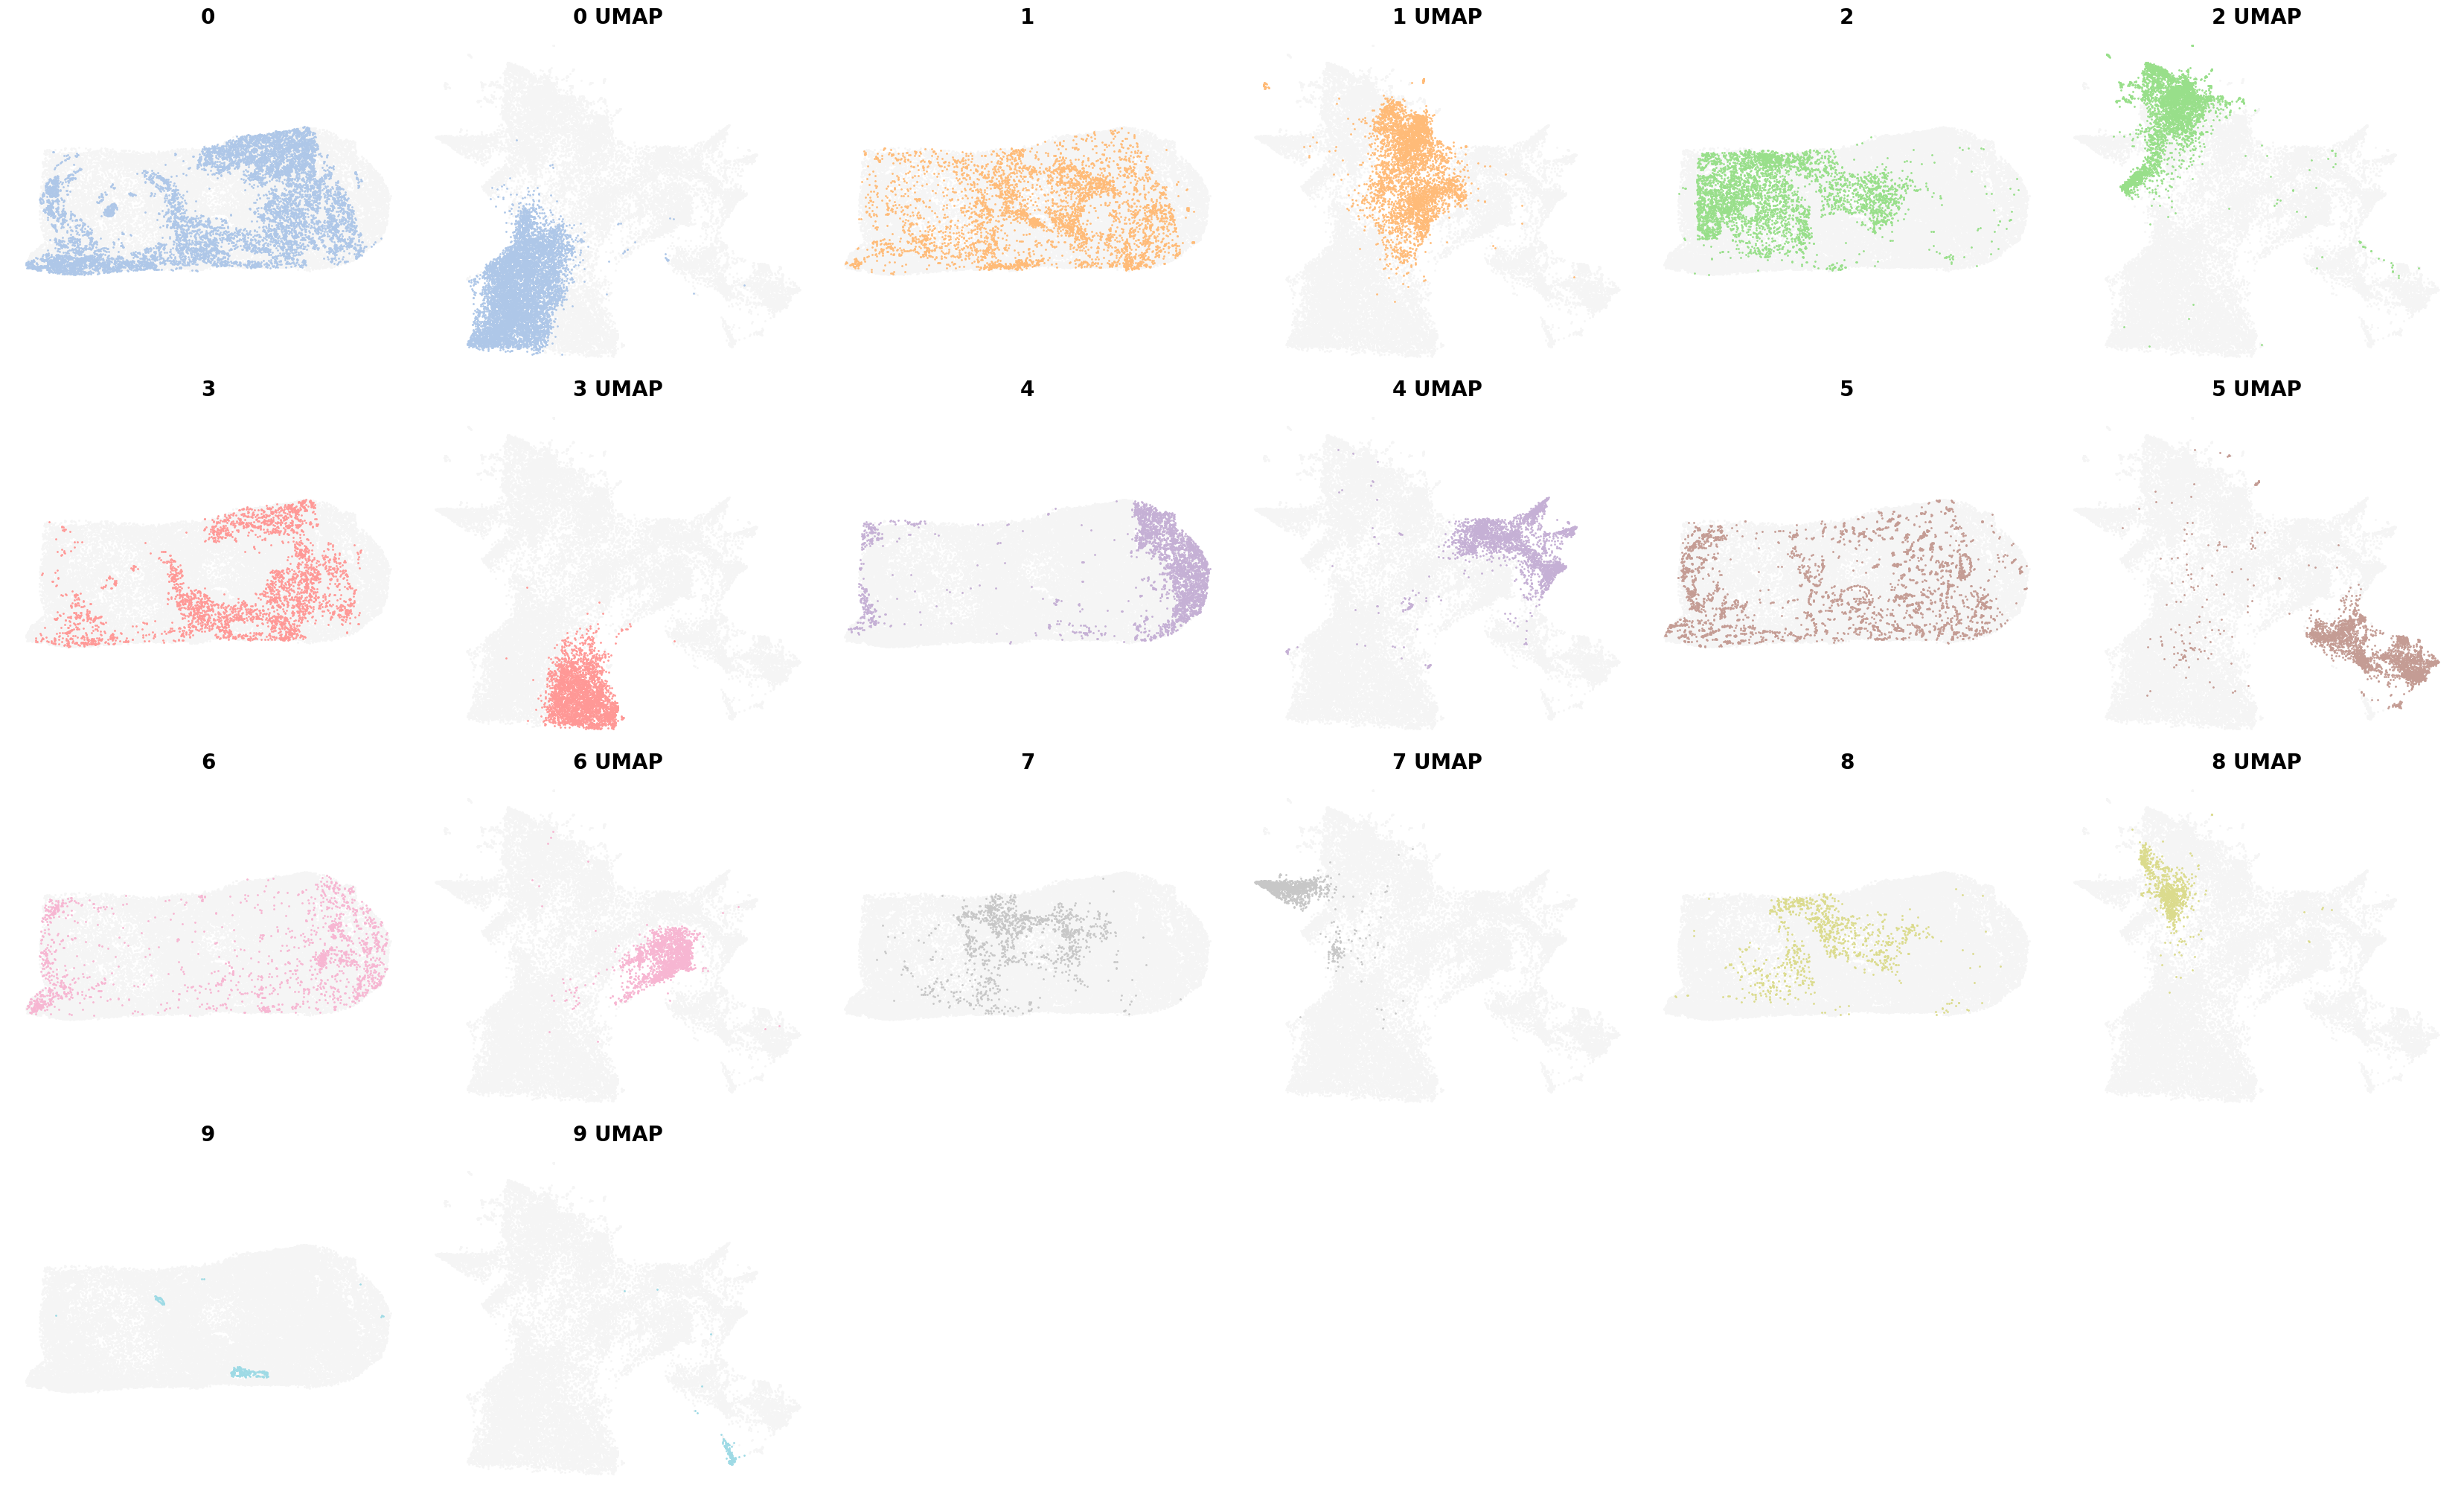

In [8]:
from banksy.plot_banksy import plot_results

c_map =  'tab20' # specify color map
weights_graph =  banksy_dict[f"{nbr_weight_decay}"]['weights'][0]

plot_results(
    results_df,
    weights_graph,
    c_map,
    match_labels = False,
    coord_keys = coord_keys,
    max_num_labels  =  max_num_labels, 
    #save_path = os.path.join(file_path, 'tmp_png'),
    save_fig = True, # save the spatial map of all clusters
    save_seperate_fig = True, # save the figure of all clusters plotted seperately
    dataset_name = f"{dataset_name}",
    save_fullfig=True,
    save_path = output_path
)

In [9]:
from banksy_utils.cluster_utils import pad_clusters, create_spatial_nonspatial_adata,  refine_cell_types

# Here we manually assign clusters to their identity using a dictionary, using just numbers as placeholders prior to manual annotation
cluster2annotation_spatial = {
    "0" : "0",
    "1" : "1",
    "2" : "2",
    "3" : "3",
    "4" : "4",
    "5" : "5",
    "6" : "6",
    "7" : "7",
    "8" : "8",
    "9" : "9"
}

pad_clusters(cluster2annotation_spatial, list(range(max_num_labels)))

cluster2annotation_nonspatial = {
    "0" : "0",
    "1" : "1",
    "2" : "2",
    "3" : "3",
    "4" : "4",
    "5" : "5",
    "6" : "6",
    "7" : "7",
    "8" : "8",
    "9" : "9",
    "10" : "10"
}

In [10]:
## Save annotations in two different anndata objects (adata_spatial and adata_nonspatial)

adata_spatial, adata_nonspatial = create_spatial_nonspatial_adata(results_df,
                                    pca_dims,
                                    lambda_list, 
                                    resolutions,
                                    cluster2annotation_spatial,
                                    cluster2annotation_nonspatial)

Using spatial params: scaled_gaussian_pc35_nc0.20_r0.50
nonspatial_pc35_nc0.00_r0.50


In [11]:
## Store the cluster labels as a string in .obs
banksy_dict[f"{nbr_weight_decay}"][0.2]['adata'] #lambda = 0.20
adata_spatial.obs[f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}"]= adata_spatial.obs[f"labels_scaled_gaussian_pc{pca_label}_nc{lambda_label}_r{res_label}"].astype(str)

In [12]:
# import pandas as pd
# import numpy as np
# from scipy.sparse import issparse

# # Check if adata.X is sparse, and convert if needed
# X = adata.X.toarray() if issparse(adata.X) else adata.X
# print(X)

# gene_df = pd.DataFrame(X, columns=adata.var_names, index=adata.obs_names)


In [13]:
# ## Pull out genes as data frame
# genes = adata.var_names
# #gene_df = pd.DataFrame(adata.X.toarray(), columns=genes, index=adata.obs_names)
# #print(gene_df)

# gene_count_across_cells = gene_df.sum(axis=0)
# gene_count_across_cells.to_frame()
# gene_count_across_cells.columns = ["gene", "counts"]

# print(gene_count_across_cells)
# gene_count_across_cells.to_csv(f"{processed_path}{dataset_name}_gene_count_across_cells_not_SCTransformed.csv")
# type(gene_count_across_cells)

# Top expressed genes per cluster

### Spatial clustering results

In [14]:
import scanpy as sc

## Rank genes and identify cluster gene markers
sc.tl.rank_genes_groups(
    adata_spatial,
    groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}",
    method='wilcoxon',
    key_added=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers"
)


In [15]:
## Check which cluster keys exist
adata_spatial.uns[f'banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers']['names'].dtype

dtype((numpy.record, [('0', 'O'), ('1', 'O'), ('2', 'O'), ('3', 'O'), ('4', 'O'), ('5', 'O'), ('6', 'O'), ('7', 'O'), ('8', 'O'), ('9', 'O')]))

In [16]:
## Using the filter_ranked_genes_by_type to create a key for 
from banksy_utils.annotation_utils import filter_ranked_genes_by_type

key_filtered = filter_ranked_genes_by_type(
    adata_spatial,
    key=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers",
    top_n=100,
    gene_type = "raw",
    new_key_suffix="_raw",
)

Copied cluster labels to adata.obs['banksy_cluster_pc35_nc0.20_r0.50_raw']
Stored filtered raw markers in adata.uns['banksy_cluster_pc35_nc0.20_r0.50_markers_raw']


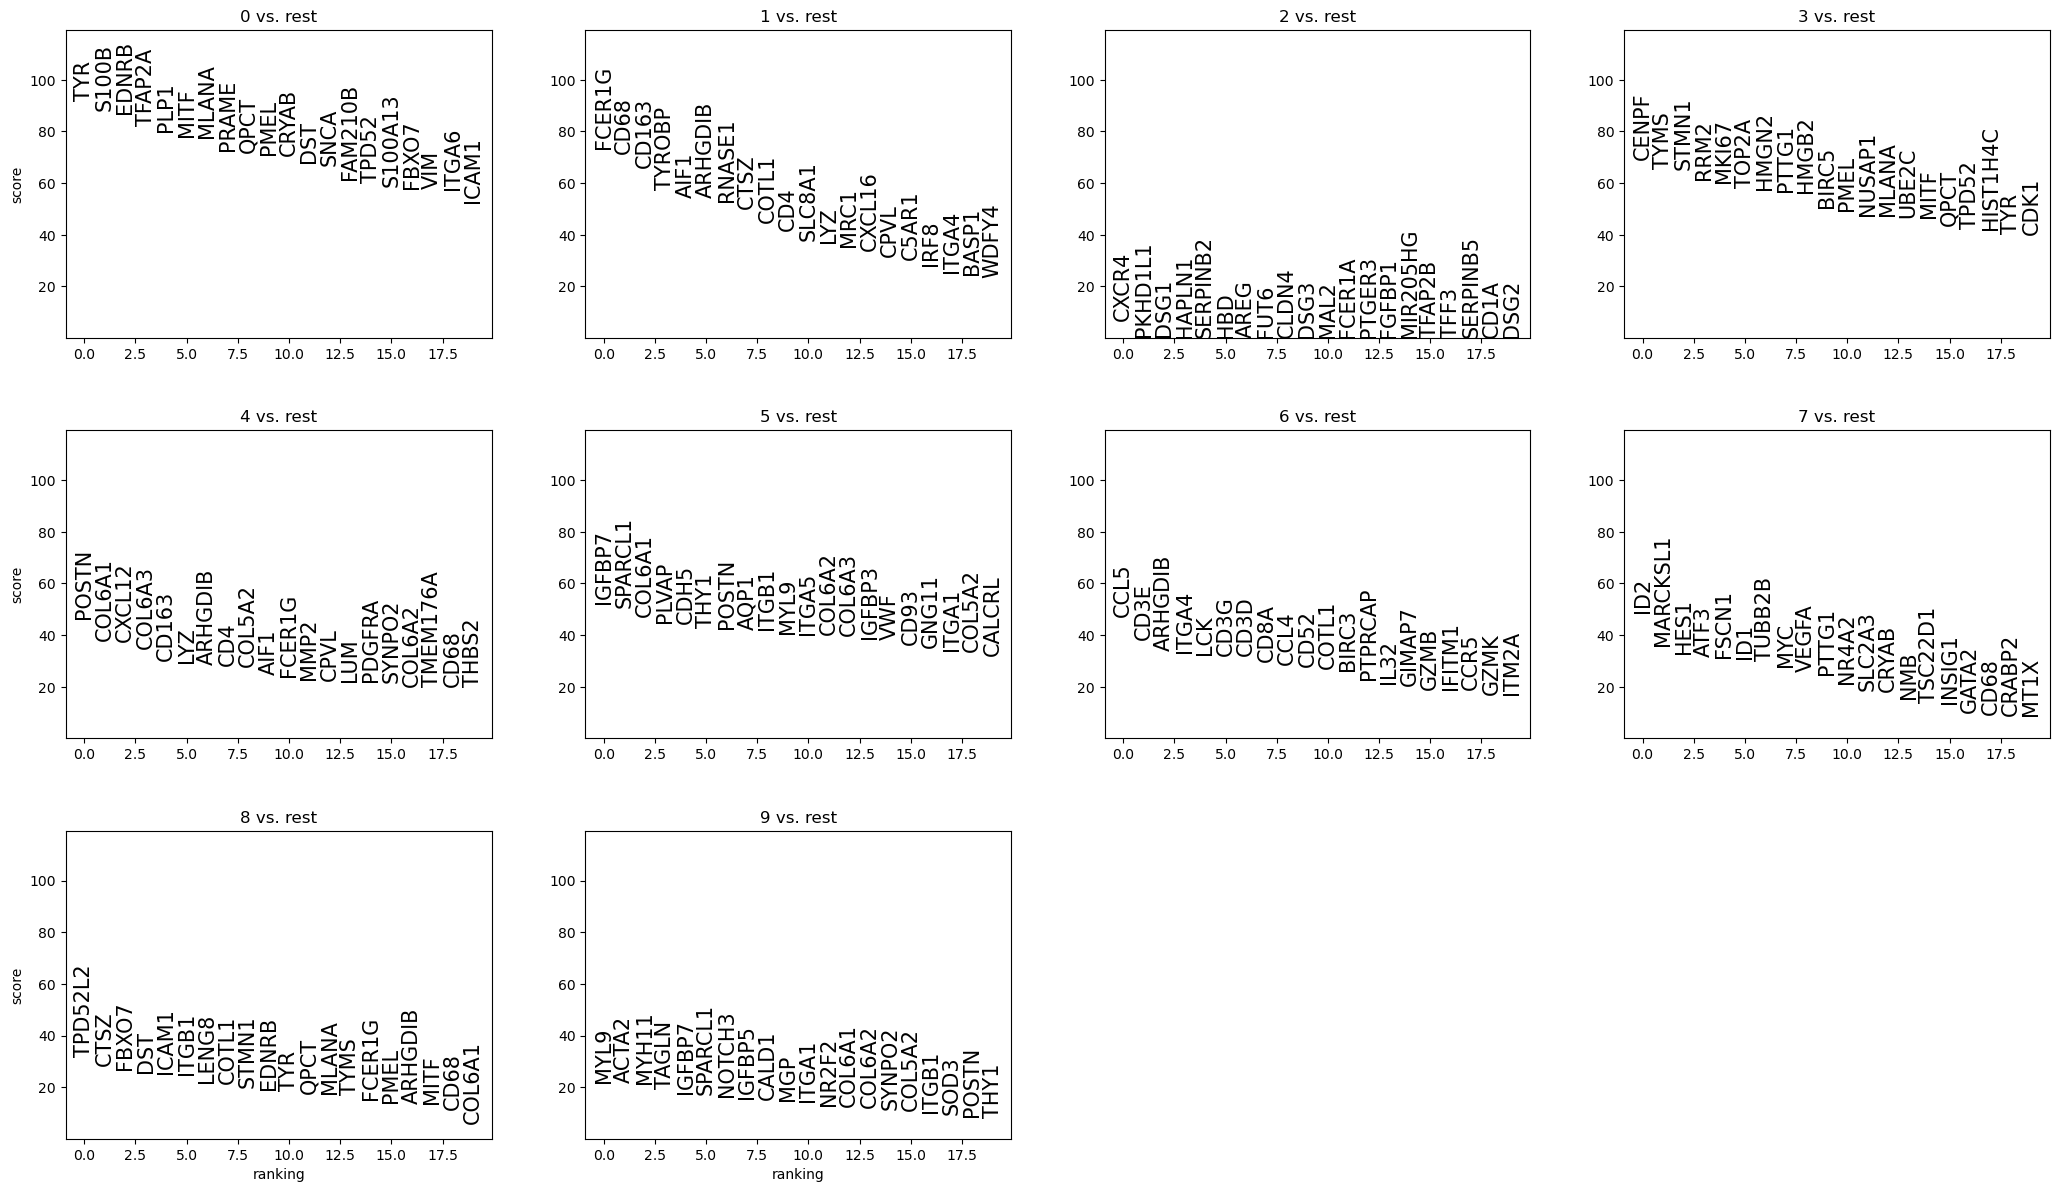

In [17]:
# Plot the gene markers for each cluster
sc.pl.rank_genes_groups(
    adata_spatial, 
    key=key_filtered,
    method='wilcoxon',
    #key=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers", 
    #key=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers_raw", 
    #key=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers_nbr_0", 
    #key=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers_nbr_1", 
    #key_added = 'banksy_cluster_pc35_nc0.20_r0.50_markers_raw',
    #key_added= "raw_test",
    n_genes=20, 
    fontsize=15,
    save= f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_spatial_top_gene_raw.png")

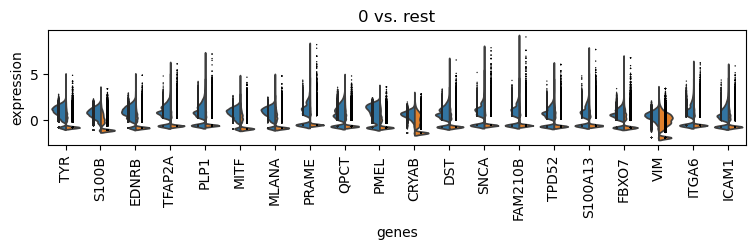

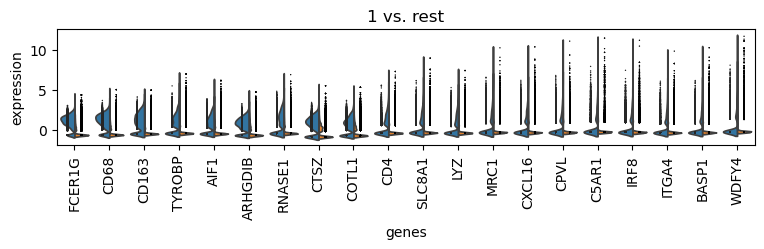

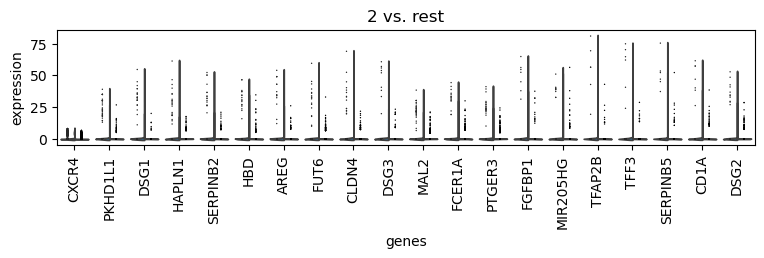

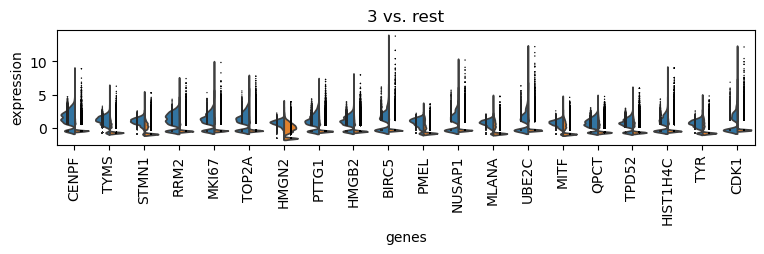

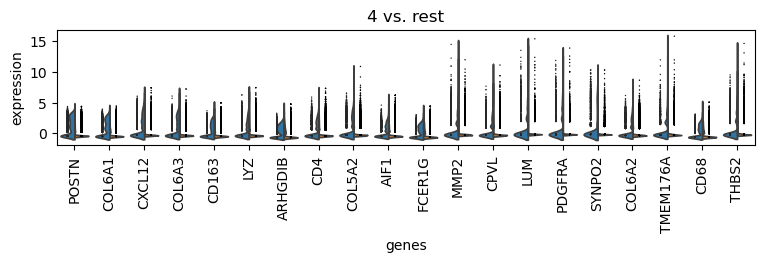

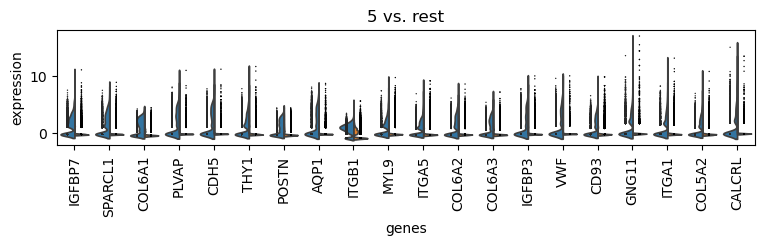

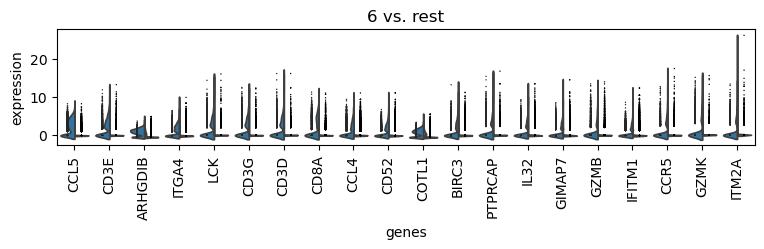

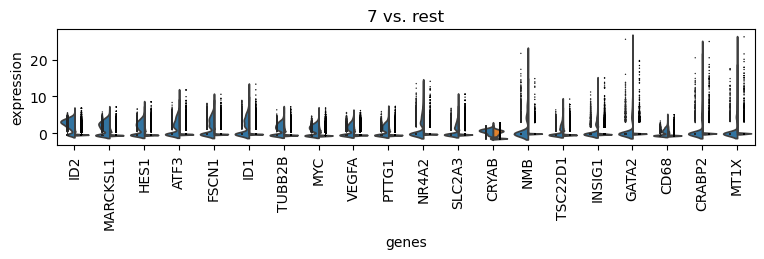

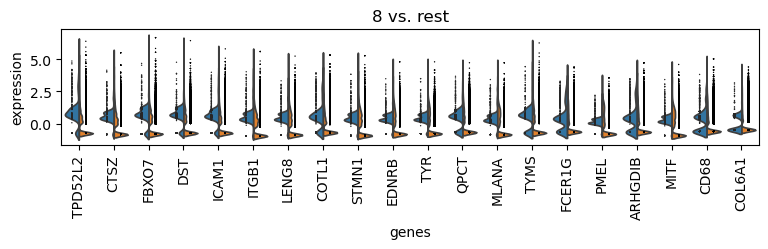

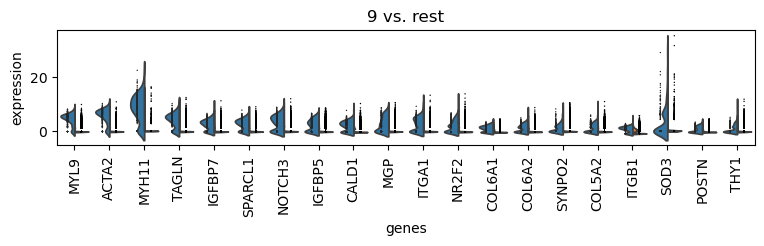

In [18]:
# Plot the gene markers for each cluster as a violin plot that conpares to every other cluster
with rc_context({"figure.figsize": (9, 1.5)}):
    sc.pl.rank_genes_groups_violin(
        adata_spatial, 
        n_genes=20, 
        jitter=False, 
        key = key_filtered
        )

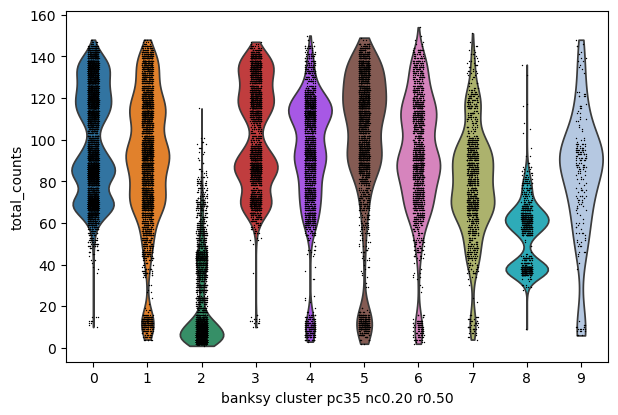

In [19]:
sc.pl.violin(
    adata_spatial, 
    "total_counts", 
    groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}", 
    save= f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.png"
    )

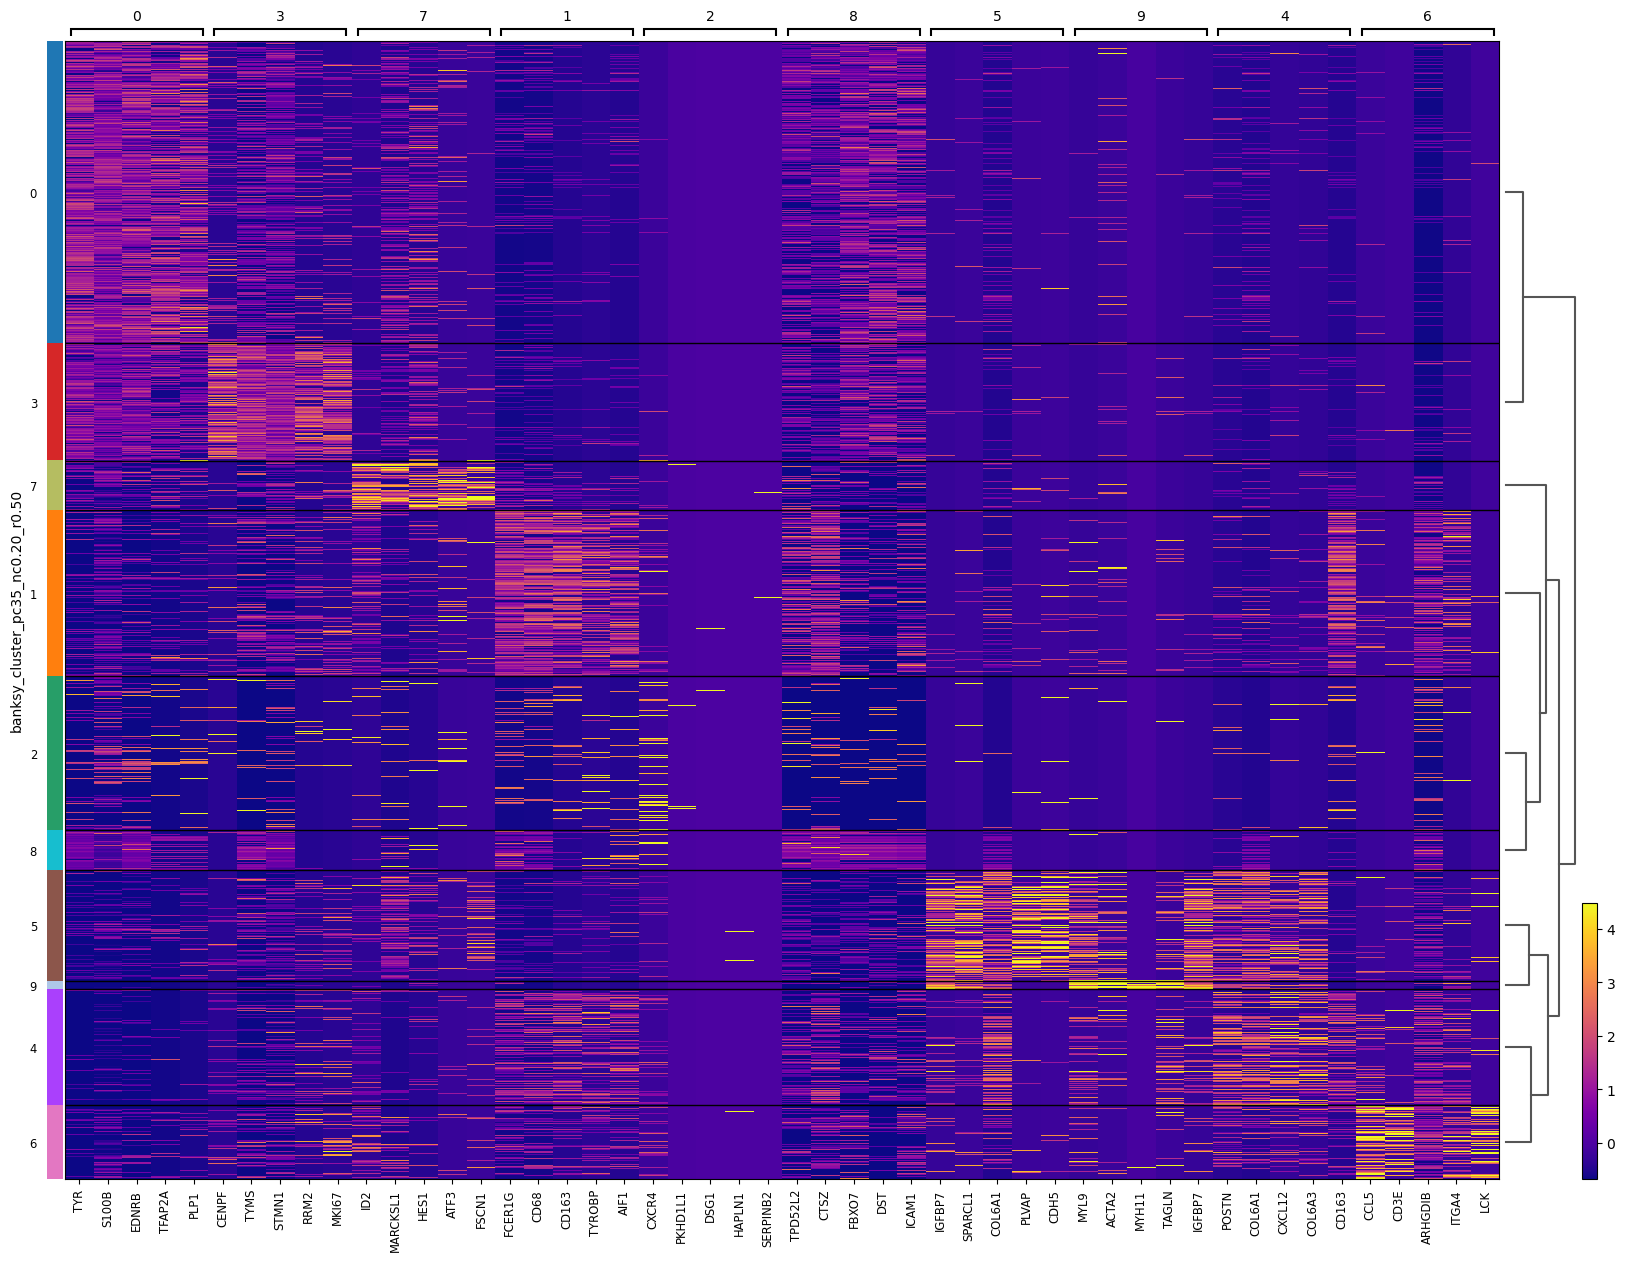

In [20]:
# Set the figure directory to your desired location
sc.settings.figdir = output_path

## Generate heat map for top markers per cluster
sc.tl.dendrogram(
    adata_spatial,
    groupby='banksy_cluster_pc35_nc0.20_r0.50_raw',
    key_added=True
)

## Determine vmin and vmax dynamically based on gene expression
expr_values = adata_spatial.X
vmax_dynamic = np.percentile(expr_values[expr_values > 0], 99)
vmin_dynamic = np.percentile(expr_values, 1)

sc.pl.rank_genes_groups_heatmap(
    adata_spatial, 
    key=f'banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers_raw',
    #key= 'raw_test',
    n_genes=5,
    cmap = "plasma",
    vmin=vmin_dynamic,
    vmax=vmax_dynamic,
    show_gene_labels = True,
    save = f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_raw_markers.png",
    figsize=(20, 15)
)

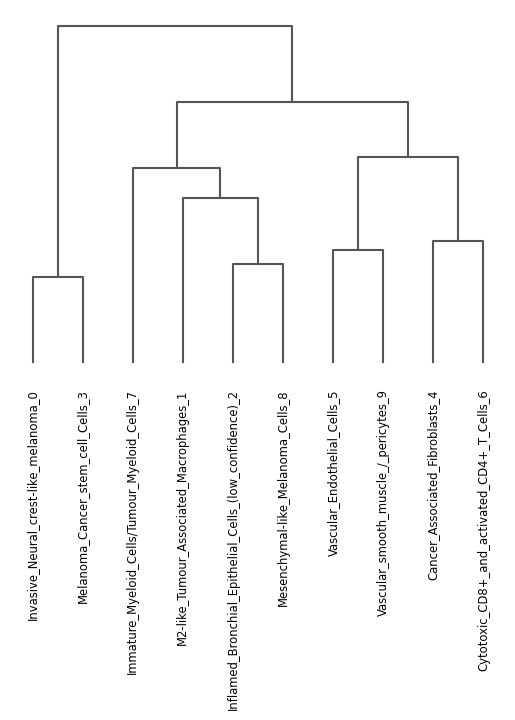

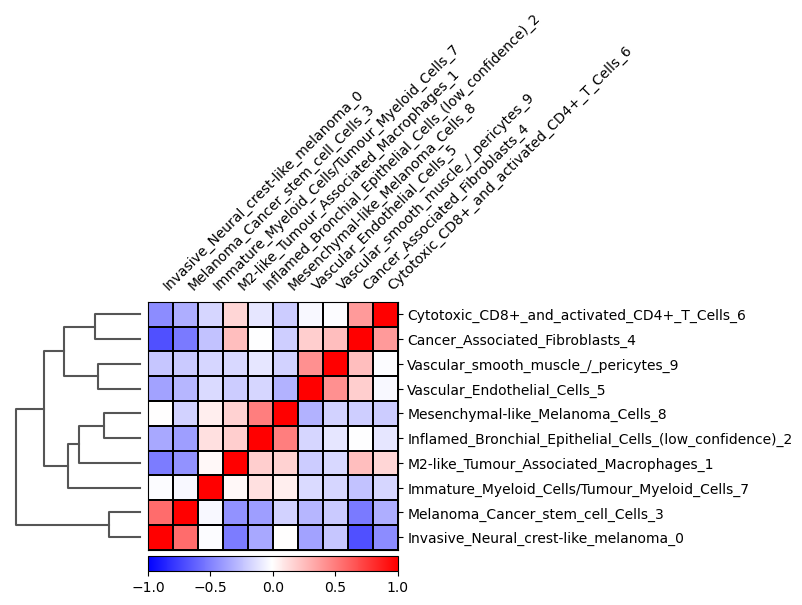

In [21]:
sc.pl.dendrogram(
    adata_spatial,
    groupby=f'banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann',
    save=f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.png"
)

sc.pl.correlation_matrix(
    adata_spatial,
    #groupby='banksy_cluster_pc35_nc0.20_r0.50_raw',
    f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann",
    save=f"{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_cluster_correlation_plot.png",
    figsize=(5, 3.5)
)

### Export the top 20 clusters in wide format to .csv

In [22]:
from banksy_utils.annotation_utils import export_clusters_wide

key= f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_markers_raw"

export_clusters_wide(
    adata= adata_spatial,
    key= key,
    gene_type= "raw",
    top_n= 20,
    dataset_name= dataset_name,
    file_path= processed_path
)

          0        1         2         3         4        5        6  \
0       TYR   FCER1G     CXCR4     CENPF     POSTN   IGFBP7     CCL5   
1     S100B     CD68   PKHD1L1      TYMS    COL6A1  SPARCL1     CD3E   
2     EDNRB    CD163      DSG1     STMN1    CXCL12   COL6A1  ARHGDIB   
3    TFAP2A   TYROBP    HAPLN1      RRM2    COL6A3    PLVAP    ITGA4   
4      PLP1     AIF1  SERPINB2     MKI67     CD163     CDH5      LCK   
5      MITF  ARHGDIB       HBD     TOP2A       LYZ     THY1     CD3G   
6     MLANA   RNASE1      AREG     HMGN2   ARHGDIB    POSTN     CD3D   
7     PRAME     CTSZ      FUT6     PTTG1       CD4     AQP1     CD8A   
8      QPCT    COTL1     CLDN4     HMGB2    COL5A2    ITGB1     CCL4   
9      PMEL      CD4      DSG3     BIRC5      AIF1     MYL9     CD52   
10    CRYAB   SLC8A1      MAL2      PMEL    FCER1G    ITGA5    COTL1   
11      DST      LYZ    FCER1A    NUSAP1      MMP2   COL6A2    BIRC3   
12     SNCA     MRC1    PTGER3     MLANA      CPVL   COL6A3  PTP

### Export the top 20 clusters in long format with scores to .csv

In [23]:
from banksy_utils.annotation_utils import export_cluster_markers

export_cluster_markers(
    adata = adata_spatial,
    key = key,
    top_n = 30,
    dataset_name = dataset_name,
    file_path = processed_path
)

### Add cell_type information to top clusters for manual annotation

In [24]:
## Read in the exported cluster markers generated with "export_clusters_wide()"
## and merge with the cell type annotation master document
n_genes_label =  20 # Set this to the number of genes that were exorted as top markers for each cluster
top_markers = pd.read_csv(f"{processed_path}/cluster_top_{n_genes_label}_genes_with_scores_{dataset_name}_{key}.csv", index_col=0) #index_col = 0 prevents insertion of an unnamed col
top_markers = top_markers.sort_index()
#print(top_markers)

## Read in the master annotation file which contains all the curated cell type labels for each marker gene
master_markers_file = pd.read_csv(f"{raw_path}/xenium_gene_list_annotation_master.csv")

## Create a data frame of the genes and their corresponding primary and secondary cell type annotations 
cell_annotations = master_markers_file[["Gene", "primary_annotation", "secondary_annotation"]]
#cell_annotations = cell_annotations.sort_index()

## Merge the top marker results and the cell type annotations
merged_markers = (
    pd.merge(
        top_markers.reset_index(), 
        cell_annotations, 
        left_on="gene", 
        right_on="Gene", 
        how="left", 
        sort="False",
        validate="m:1"
    )
    .set_index("index")
    .loc[top_markers.index]
)

merged_markers = merged_markers.drop("Gene", axis=1)
print(merged_markers)

## Export the cell type annotated top markers to .csv to use in manual annotation and ChatGPT annotation
merged_markers.to_csv(f"{processed_path}cell_type_cluster_top_{n_genes_label}_genes_{dataset_name}_{key}.csv")

     cluster    gene      score                    primary_annotation  \
0          0     TYR  91.757233                 Melanocytes; Melanoma   
1          0   S100B  88.008461  DC_AXL_SIGLEC6; Macrophages and DC_2   
2          0   EDNRB  86.976738                              Melanoma   
3          0  TFAP2A  82.414078                             TSK_basal   
4          0    PLP1  79.724991                              Melanoma   
..       ...     ...        ...                                   ...   
205        9   ITGB1  10.121636          EpSC and Other Progenitors_1   
206        9    SOD3   9.216952       Secretory-papillary Fibroblasts   
207        9   POSTN   8.504077  Fibroblasts; Mesenchymal Fibroblasts   
208        9    THY1   8.082713               Mesenchymal Fibroblasts   
209        9   INHBA   7.667495       Myeloid-derived suppressor cell   

                      secondary_annotation  
0                                      NaN  
1                                

In [25]:
## The top 20 gene markers for each cluster are assessed for cell cluster annotation

new_labels = {
    '0' : 'Invasive_Neural_crest-like_melanoma_0',
    '1' : 'M2-like_Tumour_Associated_Macrophages_1',
    '2' : 'Inflamed_Bronchial_Epithelial_Cells_(low_confidence)_2',
    '3' : 'Melanoma_Cancer_stem_cell_Cells_3',
    '4' : 'Cancer_Associated_Fibroblasts_4',
    '5' : 'Vascular_Endothelial_Cells_5', 
    '6' : 'Cytotoxic_CD8+_and_activated_CD4+_T_Cells_6',
    '7' : 'Immature_Myeloid_Cells/Tumour_Myeloid_Cells_7',
    '8' : 'Mesenchymal-like_Melanoma_Cells_8',
    '9' : 'Vascular_smooth_muscle_/_pericytes_9'
}

cluster_col = f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}"
adata_spatial.obs[f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann"] = adata_spatial.obs[cluster_col].map(new_labels)

new_labels

{'0': 'Invasive_Neural_crest-like_melanoma_0',
 '1': 'M2-like_Tumour_Associated_Macrophages_1',
 '2': 'Inflamed_Bronchial_Epithelial_Cells_(low_confidence)_2',
 '3': 'Melanoma_Cancer_stem_cell_Cells_3',
 '4': 'Cancer_Associated_Fibroblasts_4',
 '5': 'Vascular_Endothelial_Cells_5',
 '6': 'Cytotoxic_CD8+_and_activated_CD4+_T_Cells_6',
 '7': 'Immature_Myeloid_Cells/Tumour_Myeloid_Cells_7',
 '8': 'Mesenchymal-like_Melanoma_Cells_8',
 '9': 'Vascular_smooth_muscle_/_pericytes_9'}

In [26]:
## Store the UMAP results in the .obsm slot
adata_spatial.obsm['X_umap'] = banksy_dict['scaled_gaussian'][0.2]['adata'].obsm[f"reduced_pc_{pca_label}_umap"]

## Visualisations

### Cluster Annotated UMAP

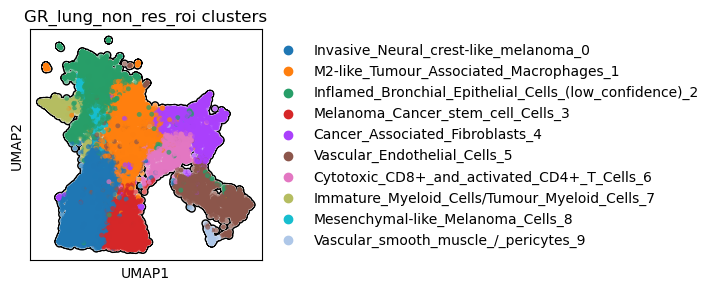

In [27]:
# Plot the umap with bulk labels
import scanpy as sc
from matplotlib.pyplot import rc_context

color_vars = [
f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann"
]

with rc_context({"figure.figsize": (3,3)}):
    sc.pl.umap(
        adata_spatial, 
        color=color_vars, 
        s=50, 
        frameon=True, 
        vmax="p99",
        add_outline=True,
        legend_fontsize=10,
        title=f"{dataset_name} clusters",
        save = f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.png"
        )

### Gene of interest UMAP plotting

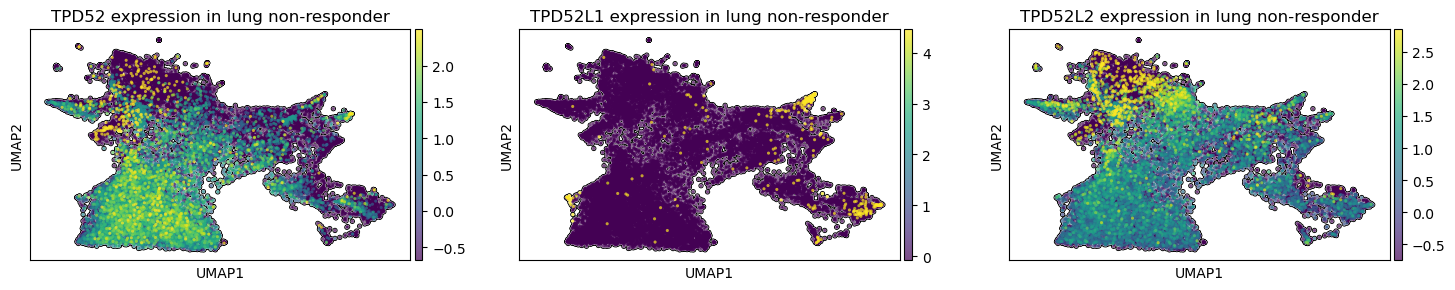

In [28]:
color_vars = [
"TPD52", "TPD52L1", "TPD52L2"
]

with rc_context({"figure.figsize": (5,3)}):
    sc.pl.umap(
        adata_spatial, 
        color=color_vars, 
        s=20, 
        frameon=True, 
        vmax="p99",
        add_outline=True,
        legend_fontsize=9,
        title=["TPD52 expression in lung non-responder", "TPD52L1 expression in lung non-responder", "TPD52L2 expression in lung non-responder"],
        save = f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_TPD52-like_genes.png"
        )

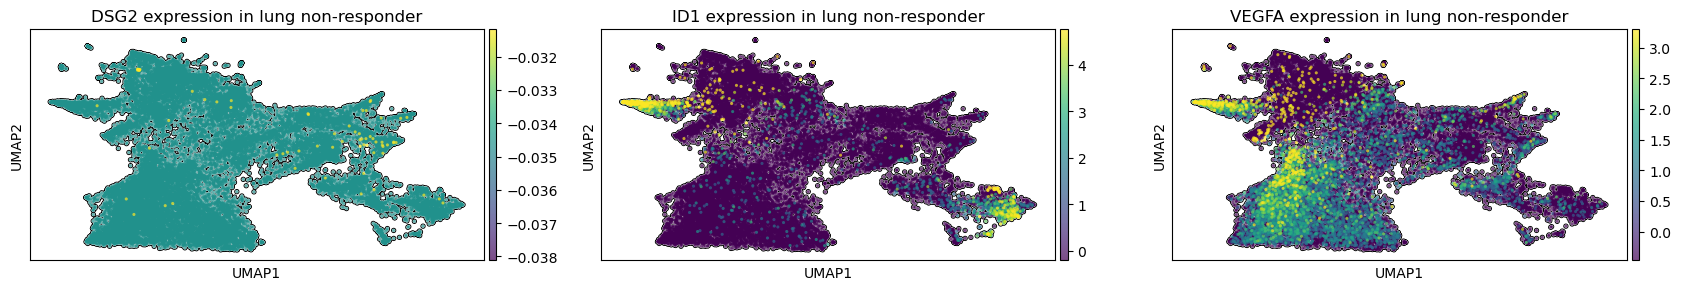

In [29]:
color_vars = [
"DSG2", "ID1", "VEGFA"
]

with rc_context({"figure.figsize": (6,3)}):
    sc.pl.umap(
        adata_spatial, 
        color=color_vars, 
        s=20, 
        frameon=True, 
        vmax="p99",
        add_outline=True,
        legend_fontsize=9,
        title=["DSG2 expression in lung non-responder", "ID1 expression in lung non-responder", "VEGFA expression in lung non-responder"],
        save = f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_DSG2_ID1_VEGFA.png"
        )

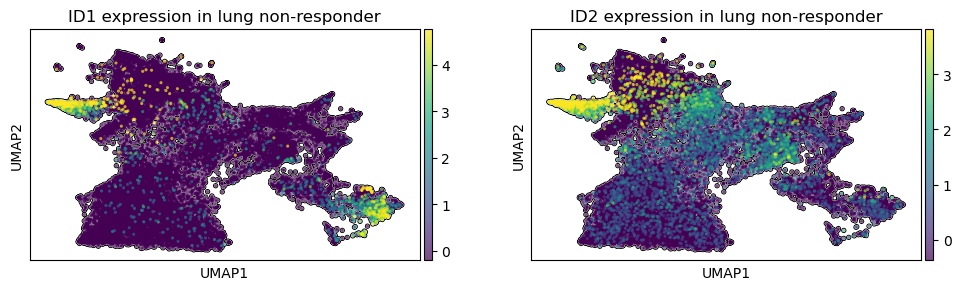

In [30]:
color_vars = [
"ID1", "ID2"
]

with rc_context({"figure.figsize": (5,3)}):
    sc.pl.umap(
        adata_spatial, 
        color=color_vars, 
        s=20, 
        frameon=True, 
        vmax="p99",
        add_outline=True,
        legend_fontsize=9,
        title=["ID1 expression in lung non-responder", "ID2 expression in lung non-responder"],
        save = f"_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_ID1_ID2.png"
        )

### Gene expression dot plots

In [31]:
from banksy_utils.annotation_utils import extract_marker_genes_dict

subset_cluster= ["Cytotoxic_CD8+_and_activated_CD4+_T_Cells_6", "Immature_Myeloid_Cells/Tumour_Myeloid_Cells_7"]

marker_genes_dict=extract_marker_genes_dict(
    adata=adata_spatial, 
    filtered_key=key_filtered, 
    gene_type='raw', 
    groupby = f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann",
    subset_cluster= subset_cluster,
    top_n=20
    )
marker_genes_dict

# Create a list of genes for this small dictionary so that the dendogram can be sorted by similarity
#marker_genes_list = marker_genes_dict["Tumour Myeloid Cells_7"]

{'Cytotoxic_CD8+_and_activated_CD4+_T_Cells_6': ['CCL5',
  'CD3E',
  'ARHGDIB',
  'ITGA4',
  'LCK',
  'CD3G',
  'CD3D',
  'CD8A',
  'CCL4',
  'CD52',
  'COTL1',
  'BIRC3',
  'PTPRCAP',
  'IL32',
  'GIMAP7',
  'GZMB',
  'IFITM1',
  'CCR5',
  'GZMK',
  'ITM2A'],
 'Immature_Myeloid_Cells/Tumour_Myeloid_Cells_7': ['ID2',
  'MARCKSL1',
  'HES1',
  'ATF3',
  'FSCN1',
  'ID1',
  'TUBB2B',
  'MYC',
  'VEGFA',
  'PTTG1',
  'NR4A2',
  'SLC2A3',
  'CRYAB',
  'NMB',
  'TSC22D1',
  'INSIG1',
  'GATA2',
  'CD68',
  'CRABP2',
  'MT1X']}

categories: Invasive_Neural_crest-like_melanoma_0, M2-like_Tumour_Associated_Macrophages_1, Inflamed_Bronchial_Epithelial_Cells_(low_confidence)_2, etc.
var_group_labels: Cytotoxic_CD8+_and_activated_CD4+_T_Cells_6, Immature_Myeloid_Cells/Tumour_Myeloid_Cells_7


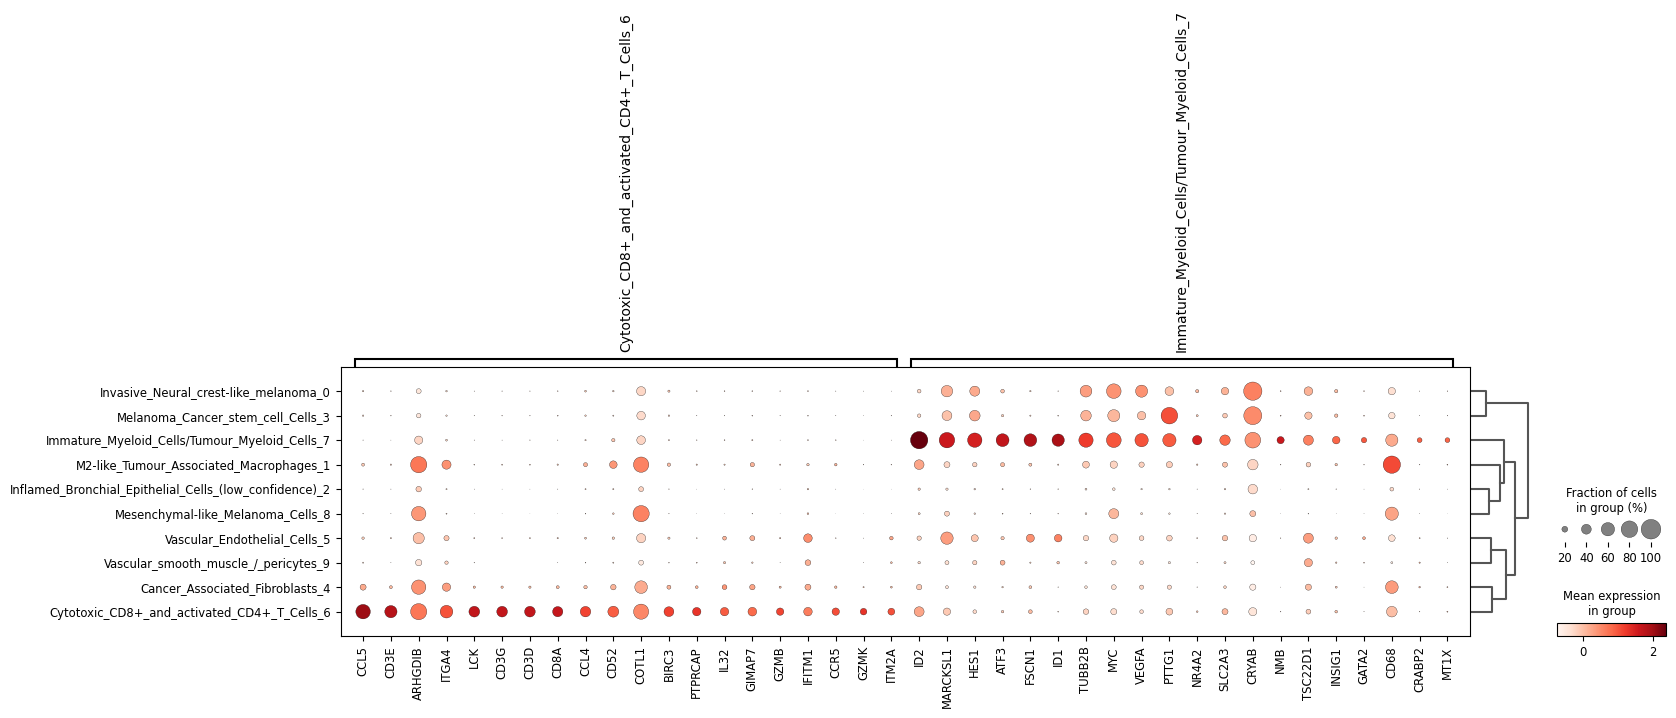

In [32]:
## Ensure that the patch line edge colopur is set to black in global matplotlib rcparams so that the bracket to group genes per cluster is shown
plt.rcParams['patch.edgecolor'] = 'black'

## Compute the dendrogram for clusters
sc.tl.dendrogram(
    adata_spatial,
    groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann"
    )

## Generate dot plot
sc.pl.dotplot(
    adata_spatial,
    #marker_genes_list,
    marker_genes_dict,
    groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann",
    dendrogram=True,
    save=f"{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_dot_plot.png"
    )

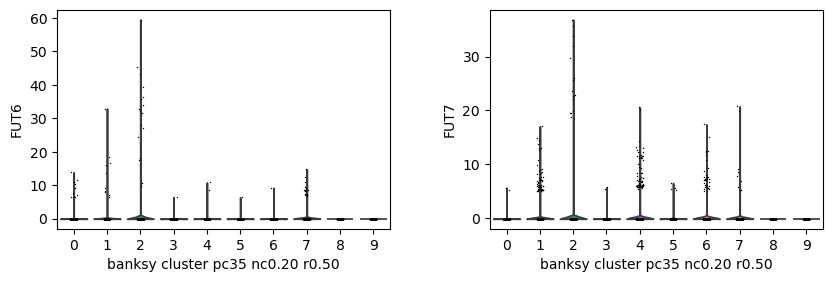

In [33]:
with rc_context({"figure.figsize": (4.5, 3)}):
    sc.pl.violin(
        adata_spatial, ["FUT6", "FUT7"], 
        groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}",
        save=f"{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_FUT6_FUT7_violin_plot.png"
        )


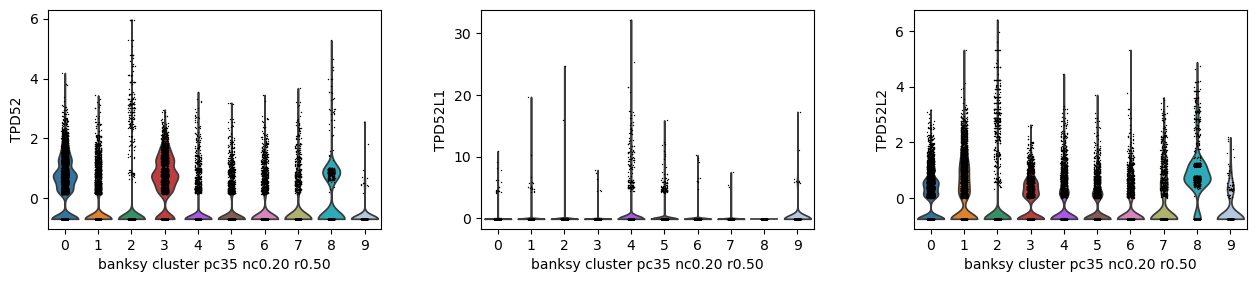

In [34]:
with rc_context({"figure.figsize": (4.5, 3)}):
    sc.pl.violin(
        adata_spatial, 
        ["TPD52", "TPD52L1", "TPD52L2"], 
        groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}",
        save=f"{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_TPD54_family_violin_plot.png"
        )

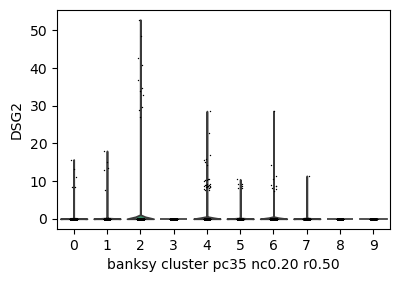

In [35]:
with rc_context({"figure.figsize": (4.5, 3)}):
    sc.pl.violin(
        adata_spatial, 
        ["DSG2"], 
        groupby=f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}",
        save=f"{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}_DSG2_violin_plot.png"
        )

## Neighbourhood enrichment analysis

In [36]:
# Adding spatial coordinates to .obsm
adata_spatial.obsm["spatial"] = adata.obs[["x", "y"]].to_numpy()

In [37]:
sq.gr.spatial_neighbors(adata_spatial)

In [38]:
cluster_key = f"banksy_cluster_pc{pca_label}_nc{lambda_label}_r{res_label}_ann"
sq.gr.nhood_enrichment(adata_spatial, cluster_key=cluster_key)

100%|██████████| 1000/1000 [00:02<00:00, 399.65/s]


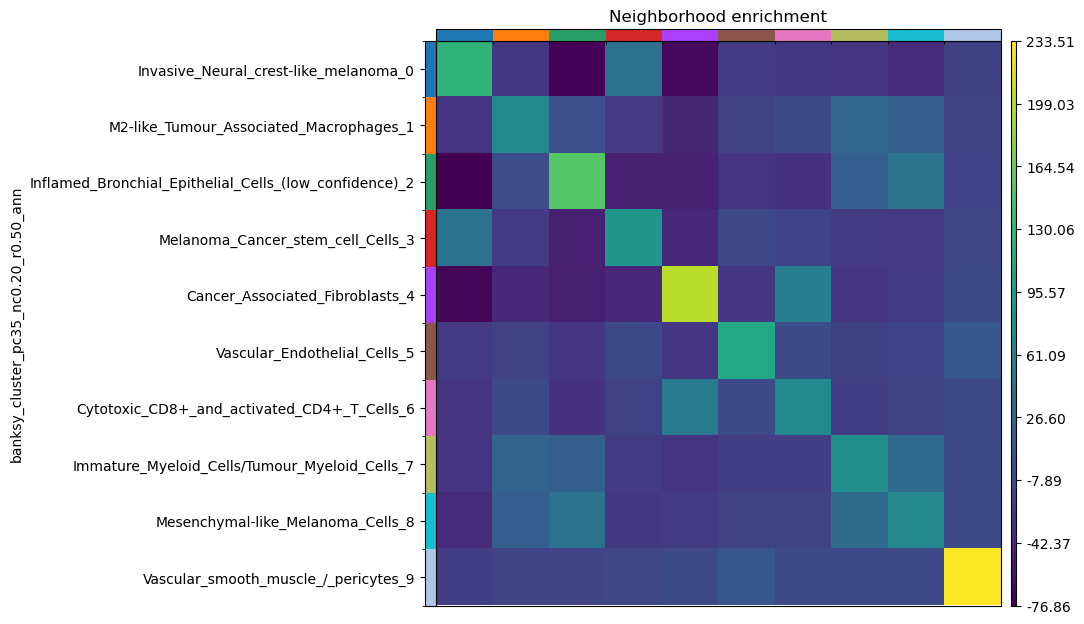

In [39]:
sq.pl.nhood_enrichment(adata_spatial, cluster_key=cluster_key)

In [40]:
# # read in the xenium data
# xenium_path = f"{raw_path}/{dataset_name}_run_folder/"
# print(xenium_path)
# print("parsing the data... ", end="")
# sdata = xenium(
#     path=xenium_path ,
#     n_jobs=8,
#     transcripts=True,
#     cells_boundaries=True,
#     nucleus_boundaries=True,
#     morphology_focus=True,
#     cells_as_circles=True,
# )
# print("done")

In [41]:
# # write out object
# xenium_path_write = "/home/nnataren/Documents/Bioinformatics/_Xenium_ICI_melanoma/xenium_melanoma_analysis/output/HW_brain_res.zarr"

# sdata.write(f"processed_path"xenium_path_write, overwrite=True)

### Moran I's score

In [45]:
## Can't create sdata if there are strings in the .uns, the code below will check the object for strings

bad_uns    = [k for k in adata_spatial.uns.keys()    if not isinstance(k, str)]
bad_obsm   = [k for k in adata_spatial.obsm.keys()   if not isinstance(k, str)]
bad_varm   = [k for k in adata_spatial.varm.keys()   if not isinstance(k, str)]
bad_layers = [k for k in adata_spatial.layers.keys() if not isinstance(k, str)]

print("uns:", bad_uns)
print("obsm:", bad_obsm)
print("varm:", bad_varm)
print("layers:", bad_layers)


uns: [True]
obsm: []
varm: []
layers: []


In [46]:
## Convert non strings to strings
if getattr(adata_spatial, "is_view", False):
    adata_spatial = adata_spatial.copy()

# 1) uns: remap non-string keys to strings
if bad_uns:
    new_uns = {}
    for k, v in adata_spatial.uns.items():
        new_uns[str(k)] = v
    adata_spatial.uns = new_uns  # safe reassignment

# 2) obsm / varm / layers: rename non-string keys in-place
def rename_nonstring_mapping(m):
    # collect renames first to avoid modifying while iterating
    to_rename = [(k, str(k)) for k in list(m.keys()) if not isinstance(k, str)]
    for old, new in to_rename:
        m[new] = m[old]
        del m[old]

rename_nonstring_mapping(adata_spatial.obsm)
rename_nonstring_mapping(adata_spatial.varm)
rename_nonstring_mapping(adata_spatial.layers)


In [47]:
adata_spatial.obs.rename(columns={"cell type": "cell_type"}, inplace=True)

from spatialdata import SpatialData

# Create SpatialData with a single table (the AnnData)
sdata = SpatialData(tables={"cells": adata_spatial})

print(sdata)


SpatialData object
└── Tables
      └── 'cells': AnnData (30203, 912)
with coordinate systems:



In [48]:
adata_spatial.uns

{'banksy_cluster_pc35_nc0.20_r0.50_markers': {'params': {'groupby': 'banksy_cluster_pc35_nc0.20_r0.50',
   'reference': 'rest',
   'method': 'wilcoxon',
   'use_raw': False,
   'layer': None,
   'corr_method': 'benjamini-hochberg'},
  'names': rec.array([('TYR', 'FCER1G', 'VIM_nbr_1', 'CENPF', 'CXCL12_nbr_0', 'SPARCL1_nbr_0', 'CCL5_nbr_0', 'ID2', 'TPD52L2', 'ACTA2_nbr_0'),
             ('TYR_nbr_0', 'CD68', 'CXCR4_nbr_1', 'CENPF_nbr_0', 'PDGFRA_nbr_1', 'CDH5_nbr_0', 'CCL5', 'ID2_nbr_0', 'CXCR4_nbr_1', 'MYL9_nbr_0'),
             ('PRAME_nbr_0', 'CD163', 'MNDA_nbr_1', 'TYMS', 'POSTN_nbr_0', 'IGFBP7_nbr_0', 'CD3E_nbr_0', 'ID2_nbr_1', 'CTSZ', 'MYH11_nbr_0'),
             ('PLP1_nbr_0', 'TYROBP', 'TYROBP_nbr_1', 'STMN1', 'LUM_nbr_1', 'PLVAP_nbr_0', 'CD3E_nbr_1', 'ATF3_nbr_0', 'CXCR4_nbr_0', 'TAGLN_nbr_0'),
             ('TFAP2A_nbr_0', 'AIF1', 'HMGN2_nbr_1', 'STMN1_nbr_0', 'LUM_nbr_0', 'VWF_nbr_0', 'CCL5_nbr_1', 'MARCKSL1', 'C5AR1_nbr_1', 'NOTCH3_nbr_0'),
             ('S100B', 'ARHGDIB', 

In [49]:
sdata.tables["subsample"] = sc.pp.subsample(adata_spatial, fraction=0.5, copy=True)

In [50]:
adata_subsample = sdata.tables["subsample"]

In [ ]:
sq.gr.spatial_neighbors(adata_subsample, coord_type="generic", delaunay=True)
sq.gr.spatial_autocorr(
    adata_subsample,
    mode="moran",
    n_perms=100,
    n_jobs=1,
)
adata_subsample.uns["moranI"].head(10)


100%|██████████| 100/100 [00:38<00:00,  2.58/s]


,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
PMEL_nbr_0,0.901642,0.0,0.000023,0.0,0.009901,0.000049,0.0,0.0,0.0105
MLANA_nbr_0,0.893846,0.0,0.000023,0.0,0.009901,0.000059,0.0,0.0,0.0105
QPCT_nbr_0,0.893747,0.0,0.000023,0.0,0.009901,0.000054,0.0,0.0,0.0105
S100B_nbr_0,0.877771,0.0,0.000023,0.0,0.009901,0.000055,0.0,0.0,0.0105
EDNRB_nbr_0,0.877418,0.0,0.000023,0.0,0.009901,0.000055,0.0,0.0,0.0105
MITF_nbr_0,0.876883,0.0,0.000023,0.0,0.009901,0.000053,0.0,0.0,0.0105
CRYAB_nbr_0,0.876154,0.0,0.000023,0.0,0.009901,0.000062,0.0,0.0,0.0105
MYH11_nbr_0,0.875821,0.0,0.000023,0.0,0.009901,0.000042,0.0,0.0,0.0105
TYR_nbr_0,0.869257,0.0,0.000023,0.0,0.009901,0.000056,0.0,0.0,0.0105
TPD52_nbr_0,0.854138,0.0,0.000023,0.0,0.009901,0.000057,0.0,0.0,0.0105


In [ ]:
## Store moran I scores as a data frame
moran_scores = adata_subsample.uns["moranI"]
moran_scores = moran_scores.reset_index(names=["Gene"])




moran_scores.to_csv(f"{processed_path}/moran_scores_{dataset_name}_pc{pca_label}_nc{lambda_label}_r{res_label}.csv")

In [ ]:
sq.pl.spatial_scatter(
    adata_subsample,
    library_id="spatial",
    color=[
        "DSG2",
        "ICAM1",
        "TPD52L2",
        "ICAM1"
    ],
    shape=None,
    size=2,
    img=False,
)

In [ ]:
# import gc to clean memory if required
# gc.collect()

In [ ]:
# write out object
# xenium_path_write = "/home/nnataren/Documents/Bioinformatics/_Xenium_ICI_melanoma/xenium_melanoma_analysis/output/EL_skin_res.zarr"

#sdata.write(xenium_path_write, overwrite=True)

In [ ]:
# Write out .zarr object
#sdata = sd.read_zarr(xenium_path_write)
# sdata

In [ ]:
# adata = sdata.tables["table"]
# adata

In [ ]:
print(adata.obsm.keys())

In [ ]:
# # Example: Adding spatial coordinates (replace with actual coordinates)
# adata.obsm["spatial"] = adata.obs[["x", "y"]].to_numpy()

In [ ]:
print(adata.obs.columns)  # Look for columns like "x", "y", "spatial_x", "spatial_y"


In [ ]:
print(adata.obsm.keys())

In [ ]:
sc.pp.calculate_qc_metrics(adata, percent_top=(10, 20, 50, 150), inplace=True)

In [ ]:
print(adata.obs.columns)  

In [ ]:
sc.pp.pca(adata)

In [ ]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

In [ ]:
pca_values = adata.obsm["X_pca"]
print(pca_values)
adata.obsm["X_pca"]

In [ ]:
print(adata. __repr__())

In [ ]:
sc.pp.neighbors(adata, knn=True, n_neighbors = 15, n_pcs = 14)

In [ ]:
sc.tl.umap(adata)

In [ ]:
import igraph as ig
ig.config['max_threads'] = "4"

In [ ]:
## A set of clustering solutions
for res in [0.1, 0.25, 0.5, 0.7, 1.0]:
    sc.tl.leiden(
        adata, 
        key_added=f"leiden_res_{res:4.2f}",
        resolution=res,
        flavor="igraph", 
        n_iterations=2
    )

In [ ]:
# sc.pl.umap(
#     adata,
#     color=[
#         "total_counts",
#         "n_genes_by_counts",
#         "leiden",
#     ],
#     wspace=0.4,
# )

In [ ]:
adata

In [ ]:
sc.pl.umap(
    adata,
    color=[
        "leiden_res_0.10",
        "leiden_res_0.25",
        "leiden_res_0.50",
        "leiden_res_0.70",
        "leiden_res_1.00",
    ],
    wspace=0.4,
)

In [ ]:
#adata.uns.pop('leiden_colors')
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "leiden_res_1.00"
    ],
    wspace=0.4,
)

In [ ]:
print(adata.obs.columns)

In [ ]:
# Obtain cluster-specific differentially expressed genes
sc.tl.rank_genes_groups(adata, groupby="leiden_res_0.50", method="wilcoxon")

## Building a spatial neighbourhood graph

In [ ]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)

## Compute centrality scores

In [ ]:
sq.gr.centrality_scores(adata, cluster_key=cluster_key)

In [ ]:
sq.pl.centrality_scores(adata, cluster_key=cluster_key, figsize=(10, 5))

## Compute co-occurence probability

In [ ]:
from spatialdata import SpatialData
sdata = SpatialData()

In [ ]:
sdata.tables["subsample"] = sc.pp.subsample(adata, fraction=0.5, copy=True)

In [ ]:
adata_subsample = sdata.tables["subsample"]

In [ ]:
sq.gr.co_occurrence(
    adata_subsample,
    cluster_key="leiden",
)
sq.pl.co_occurrence(
    adata_subsample,
    cluster_key="leiden",
    clusters="12",
    figsize=(10, 10),
)
sq.pl.spatial_scatter(
    adata_subsample,
    color="leiden",
    shape=None,
    size=2,
)

## Neighbours enrichment analysis

In [ ]:
sq.gr.nhood_enrichment(adata, cluster_key="leiden")

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 7))
sq.pl.nhood_enrichment(
    adata,
    cluster_key="leiden",
    figsize=(8, 8),
    title="Neighborhood enrichment adata",
    ax=ax[0],
)
sq.pl.spatial_scatter(adata_subsample, color="leiden", shape=None, size=2, ax=ax[1])

## Compute Moran's score

In [ ]:
sq.gr.spatial_neighbors(adata_subsample, coord_type="generic", delaunay=True)
sq.gr.spatial_autocorr(
    adata_subsample,
    mode="moran",
    n_perms=100,
    n_jobs=1,
)

In [ ]:
moran = adata_subsample.uns["moranI"].sort_values(by='pval_norm', ascending=True)
moran

In [ ]:
print(adata_subsample.uns["moranI"].head(20))
import pandas as pd
moran = adata_subsample.uns["moranI"].sort_values(by='I', ascending=False)
moran
moran.to_csv('output/moran_scores.csv')#adata_subsample.uns["moranI"].head(10)
import pandas as pd
moran = adata_subsample.uns["moranI"].sort_values(by='I', ascending=False)
moran
moran.to_csv('output/moran_scores.csv')

In [ ]:
sq.pl.spatial_scatter(
    adata_subsample,
    library_id="spatial",
    color=[
        "DSG2",
        "PTGDS",
        "PTN",
        "S100B",
        "PMEL",
        "QPCT",
        "EDNRB",
        "MGP",  
    ],
    shape=None,
    size=5,
    img=False,
)

In [ ]:
sq.pl.spatial_scatter(
    adata_subsample,
    library_id="spatial",
    color=[

        "TYRP1",  
        "SPARCL1",
        "VWF",
        "MYH11",
        "IGFBP5",
        "IFITM1",
        "APOD",
        "DCT"      
    ],
    shape=None,
    size=3,
    img=False,
)

In [ ]:
import spatialdata_plot

gene_name = ["GALNT6", "LINC00636"]
for name in gene_name:
    sdata.pl.render_images("morphology_focus").pl.render_shapes(
        "cell_circles",
        color=name,
        table_name="table",
        use_raw=False,
    ).pl.show(
        title=f"{name} expression over Morphology image",
        coordinate_systems="global",
        figsize=(10, 5),
    )